In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
%matplotlib inline
import os

In [ ]:
import SigProfilerExtractor
import os
print(os.path.dirname(SigProfilerExtractor.__file__))

In [4]:
import shutil
import pandas as pd

all_sol_1_10 = sbs_1_10 / "All_Solutions"
all_sol_11_15 = sbs_11_15 / "All_Solutions"

# Carpeta de destino para la fusión
out_merged = out_1_10.parent / "extraccion_pulmon_1_15" / "SBS96"
all_sol_merged = out_merged / "All_Solutions"
all_sol_merged.mkdir(parents=True, exist_ok=True)

# Copiar las 15 subcarpetas de soluciones
for src in [all_sol_1_10, all_sol_11_15]:
    for sol_folder in src.iterdir():
        dest = all_sol_merged / sol_folder.name
        if not dest.exists():
            shutil.copytree(sol_folder, dest)

print("Subcarpetas fusionadas:", sorted(p.name for p in all_sol_merged.iterdir()))

# Fusionar el CSV (concatenar tal cual, sin tocar Considerable Solution/P-value:
# se recalculan al volver a correr estimate_solution)
df_merged = pd.concat([df1, df2], ignore_index=True)
df_merged["k_orden"] = df_merged["Signatures"].str.replace("*", "", regex=False).astype(int)
df_merged = df_merged.sort_values("k_orden").drop(columns="k_orden").reset_index(drop=True)

df_merged.to_csv(out_merged / "All_solutions_stat.csv", index=False)
print(df_merged[["Signatures", "Stability (Avg Silhouette)", "Minimum Stability", "Considerable Solution"]])

Subcarpetas fusionadas: ['SBS96_10_Signatures', 'SBS96_11_Signatures', 'SBS96_12_Signatures', 'SBS96_13_Signatures', 'SBS96_14_Signatures', 'SBS96_15_Signatures', 'SBS96_1_Signatures', 'SBS96_2_Signatures', 'SBS96_3_Signatures', 'SBS96_4_Signatures', 'SBS96_5_Signatures', 'SBS96_6_Signatures', 'SBS96_7_Signatures', 'SBS96_8_Signatures', 'SBS96_9_Signatures']
   Signatures  Stability (Avg Silhouette)  Minimum Stability  \
0           1                        1.00               1.00   
1           2                        1.00               1.00   
2           3                        1.00               1.00   
3           4                        1.00               0.99   
4           5                        0.99               0.95   
5           6                        0.87               0.40   
6           7                        0.70              -0.57   
7           8                        0.93               0.86   
8          9*                        0.91               0.84   

In [5]:
samples_1 = (sbs_1_10 / "Samples.txt").read_text()
samples_2 = (sbs_11_15 / "Samples.txt").read_text()

print("¿Son idénticos?", samples_1 == samples_2)

¿Son idénticos? True


In [6]:
shutil.copy(sbs_1_10 / "Samples.txt", out_merged / "Samples.txt")

from SigProfilerExtractor import estimate_best_solution as ebs

ebs.estimate_solution(
    base_csvfile=str(out_merged / "All_solutions_stat.csv"),
    All_solution=str(out_merged / "All_Solutions"),
    genomes=str(out_merged / "Samples.txt"),
    output=str(out_merged / "Selection_1_15"),
    title="Selection_Plot_1_15",
    stability=0.8,
    min_stability=0.2,
    combined_stability=1.0,
    allow_stability_drop=False,
    exome=False
)

9

In [8]:
import os
os.startfile(selection_folder / "SBS96_selection_plot.pdf")

In [9]:
print(list((all_sol_merged / "SBS96_9_Signatures").rglob("*")))

[WindowsPath('C:/Users/quiqu/OneDrive/Escritorio/GITHUB/SigProfilerExtractor_Noise/Analisis Quique/resultados/extraccion_pulmon_1_15/SBS96/All_Solutions/SBS96_9_Signatures/Activities'), WindowsPath('C:/Users/quiqu/OneDrive/Escritorio/GITHUB/SigProfilerExtractor_Noise/Analisis Quique/resultados/extraccion_pulmon_1_15/SBS96/All_Solutions/SBS96_9_Signatures/Signatures'), WindowsPath('C:/Users/quiqu/OneDrive/Escritorio/GITHUB/SigProfilerExtractor_Noise/Analisis Quique/resultados/extraccion_pulmon_1_15/SBS96/All_Solutions/SBS96_9_Signatures/Solution_Stats'), WindowsPath('C:/Users/quiqu/OneDrive/Escritorio/GITHUB/SigProfilerExtractor_Noise/Analisis Quique/resultados/extraccion_pulmon_1_15/SBS96/All_Solutions/SBS96_9_Signatures/Activities/SBS96_S9_NMF_Activities.txt'), WindowsPath('C:/Users/quiqu/OneDrive/Escritorio/GITHUB/SigProfilerExtractor_Noise/Analisis Quique/resultados/extraccion_pulmon_1_15/SBS96/All_Solutions/SBS96_9_Signatures/Activities/SBS96_S9_NMF_Activities_SEM_Error.txt'), Wind

In [10]:
import pandas as pd
import numpy as np

samples_path = out_merged / "Samples.txt"
M = pd.read_csv(samples_path, sep="\t", index_col=0)

U_por_k = {}
resumen = []

for k in range(1, 16):
    folder = all_sol_merged / f"SBS96_{k}_Signatures"
    sig_file = folder / "Signatures" / f"SBS96_S{k}_Signatures.txt"
    act_file = folder / "Activities" / f"SBS96_S{k}_NMF_Activities.txt"

    try:
        S = pd.read_csv(sig_file, sep="\t", index_col=0)
        A = pd.read_csv(act_file, sep="\t", index_col=0)

        # alinear filas (tipos de mutación) y columnas (muestras) con M
        S = S.loc[M.index]
        A = A.loc[M.columns]

        # S: (96 x k) ; A cargado como (muestras x k) -> trasponer a (k x muestras)
        U = M.values - S.values @ A.values.T
        U_por_k[k] = pd.DataFrame(U, index=M.index, columns=M.columns)

        frob_rel = 100 * np.linalg.norm(U) / np.linalg.norm(M.values)
        resumen.append({"K": k, "Frobenius%_calculado": round(frob_rel, 2)})

    except FileNotFoundError as e:
        print(f"K={k}: no encontrado -> {e}")

df_resumen = pd.DataFrame(resumen)
print(df_resumen)

     K  Frobenius%_calculado
0    1                 41.36
1    2                 21.54
2    3                 14.98
3    4                 12.57
4    5                 11.60
5    6                 10.75
6    7                 10.11
7    8                  5.56
8    9                  4.85
9   10                  4.47
10  11                  4.16
11  12                  3.92
12  13                  3.91
13  14                  3.50
14  15                  3.48


In [11]:
out_U = out_merged / "U_por_K"
out_U.mkdir(exist_ok=True)

for k, U_df in U_por_k.items():
    U_df.to_csv(out_U / f"U_K{k}.csv")

print("Guardadas en:", out_U)

Guardadas en: C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\Analisis Quique\resultados\extraccion_pulmon_1_15\SBS96\U_por_K


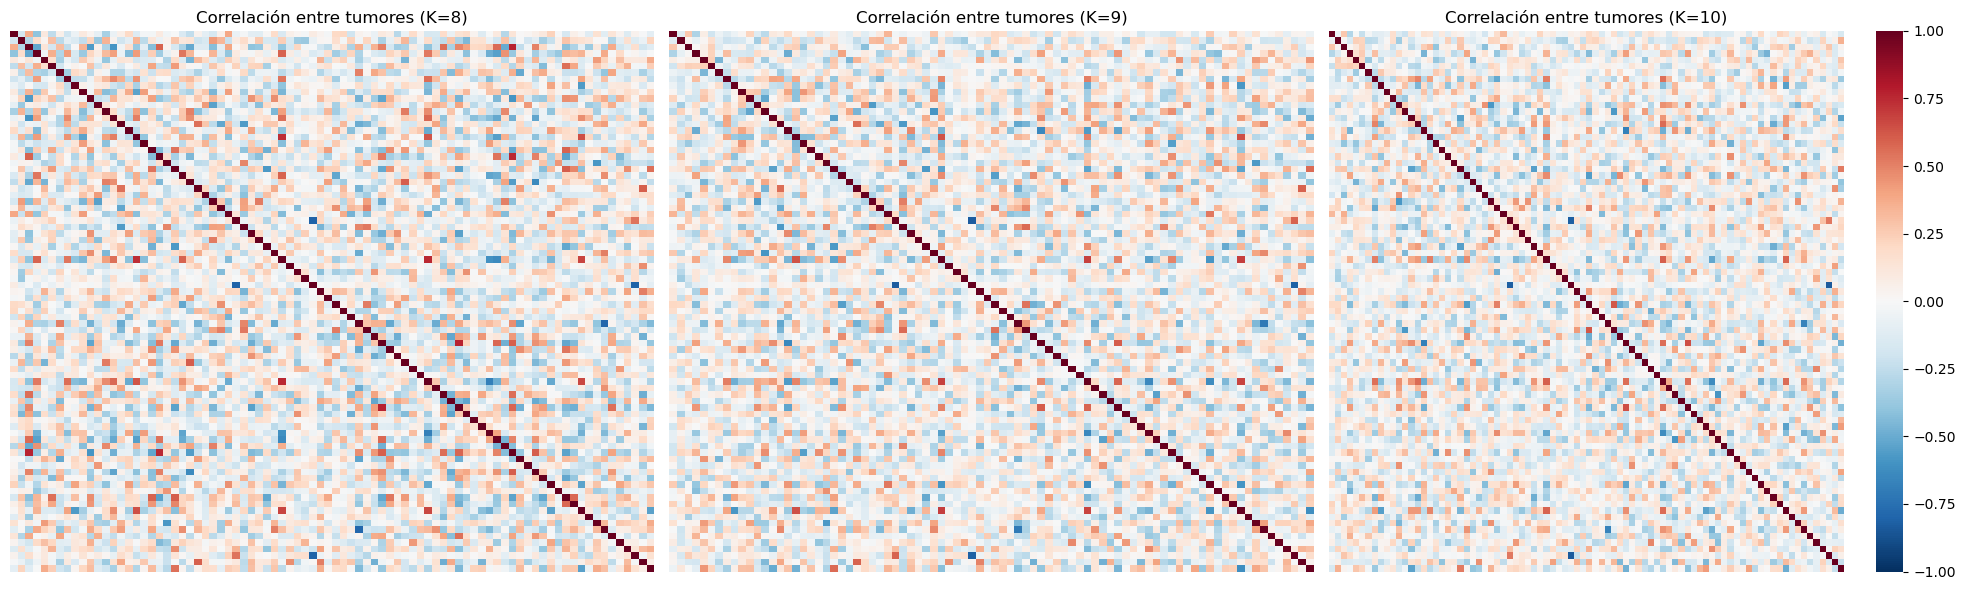

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

ks = [8, 9, 10]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, k in zip(axes, ks):
    corr = U_por_k[k].corr()  # correlación entre columnas = entre muestras/tumores
    sns.heatmap(
        corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        xticklabels=False, yticklabels=False,
        cbar=(ax == axes[-1])
    )
    ax.set_title(f"Correlación entre tumores (K={k})")

plt.tight_layout()
plt.show()

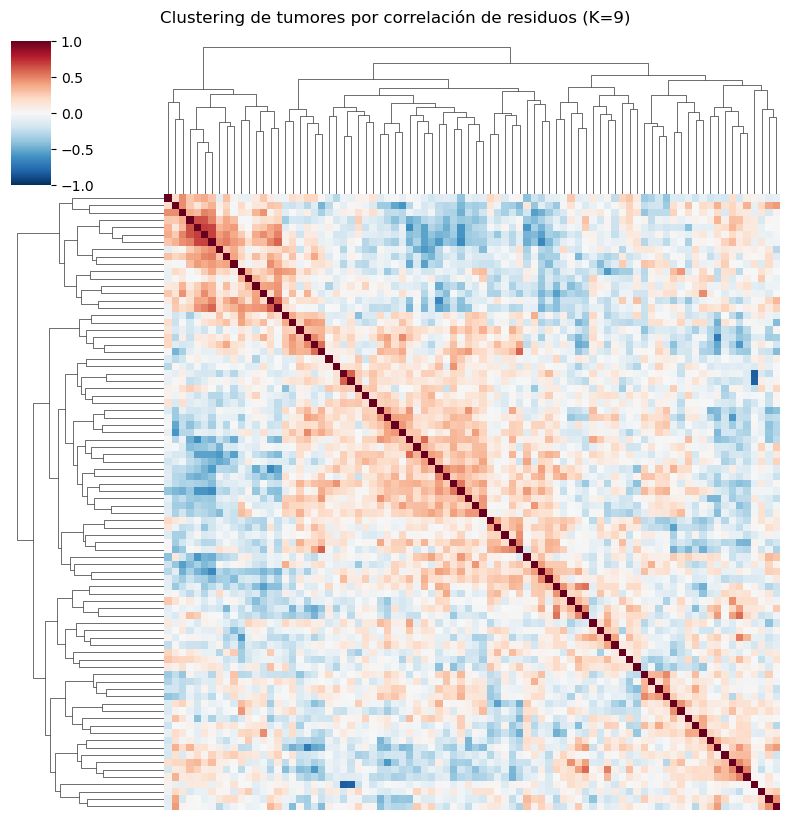

In [17]:
k = 9  # el K elegido
corr = U_por_k[k].corr()

g = sns.clustermap(
    corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=False, yticklabels=False,
    figsize=(8, 8)
)
g.fig.suptitle(f"Clustering de tumores por correlación de residuos (K={k})", y=1.02)
plt.show()